# Predicting Premier League Transfer Value Growth

Goal: for each player currently valued in the Premier League, predict how much their transfer market value will change over the next 3, 6, 9, and 12 months, and rank who's projected to rise the most.

Approach: build a panel of historical valuation "snapshots" (one row per past valuation event) with trailing-365-day performance features known as of that date, and a forward-looking value-change target at each horizon (the nearest actual future valuation). Train a linear baseline, Ridge, Lasso, and XGBoost per horizon, then apply the best model to each player's most recent snapshot to generate forward-looking predictions.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.panel import HORIZONS_MONTHS, build_snapshot_panel
from src.modeling import latest_snapshot_per_player, predict_value_growth, train_horizon_models

sns.set_theme(style="whitegrid")
USD_PER_EUR = 1.08  # same fixed rate used in 01_eda.ipynb, for readability only

panel = build_snapshot_panel()
panel.shape

(33743, 33)

## Target coverage by horizon

Not every snapshot has a matched future valuation within tolerance (this dataset re-values players roughly every 150-190 days on average), so the 3-month horizon has noticeably fewer usable rows than the others.

In [2]:
coverage = pd.DataFrame(
    {
        "months": HORIZONS_MONTHS,
        "rows_with_target": [panel[f"value_change_{m}m_pct"].notna().sum() for m in HORIZONS_MONTHS],
        "pct_of_panel": [round(panel[f"value_change_{m}m_pct"].notna().mean() * 100, 1) for m in HORIZONS_MONTHS],
    }
)
coverage

,months,rows_with_target,pct_of_panel
0,3,8721,25.8
1,6,24493,72.6
2,9,26542,78.7
3,12,26038,77.2


## Target distribution by horizon

Value change is heavily right-skewed at every horizon (a few breakout players multiply their value many times over) with a spike at 0% (many snapshots simply aren't re-valued within the window). The x-axis below is clipped to ±200% for readability.

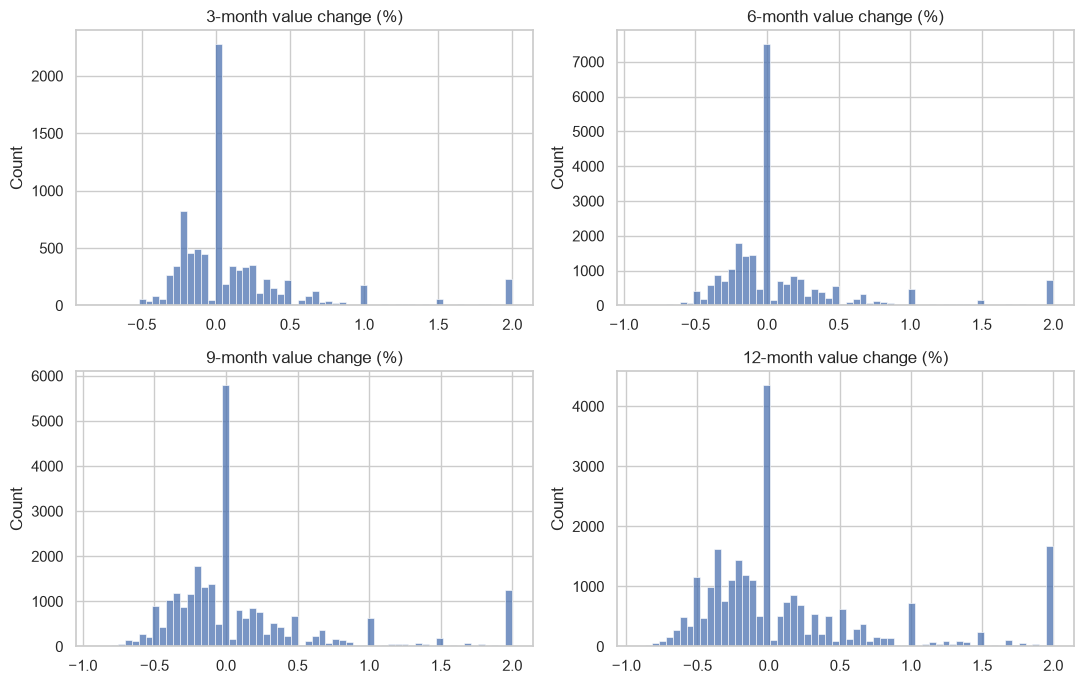

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, months in zip(axes.flat, HORIZONS_MONTHS):
    col = f"value_change_{months}m_pct"
    data = panel[col].dropna().clip(-2, 2)
    sns.histplot(data, bins=60, ax=ax)
    ax.set_title(f"{months}-month value change (%)")
    ax.set_xlabel(None)
plt.tight_layout()
plt.show()

## Modeling approach

For each horizon, train four regressors on the same features:

- **Features**: log10(current value), age, age² (captures the peak-then-decline age curve from the EDA notebook), trailing goals/assists per-90, trailing minutes, trailing appearances, trailing average league position of the player's club (team-strength context), months since last transfer, number of prior transfers, log(last transfer fee), sub-position, preferred foot.
- **Models**: `LinearRegression` (baseline), `Ridge`, `Lasso`, `XGBRegressor`.
- **Split**: time-based (train on earlier snapshots, test on the most recent 20%) so the model is evaluated on genuinely future data, not a random shuffle that would leak information across a player's own history.
- **Target clipping**: value-change % is capped at [-95%, +500%] before fitting, so a handful of extreme breakout cases don't dominate the squared-error loss.

Note: `players.csv` also has `contract_expiration_date` and international caps/goals, but those are current-as-of-scrape snapshots rather than dated historical series — using them on old valuation rows would leak future information into the past, so they're excluded. The transfer-history and club-position features above come from genuinely dated tables (`transfers.csv`, `games.csv`) instead.

In [4]:
all_results = {months: train_horizon_models(panel, months) for months in HORIZONS_MONTHS}

metrics = pd.DataFrame(
    [
        {"months": months, "model": name, **{k: v for k, v in r.items() if k != "pipeline"}}
        for months, results in all_results.items()
        for name, r in results.items()
    ]
)
metrics.sort_values(["months", "mae"])

,months,model,mae,rmse,r2,n_train,n_test
3,3,xgboost,0.207180,0.441074,0.317951,7032,1688
2,3,lasso,0.219845,0.453278,0.279685,7032,1688
1,3,ridge,0.229287,0.452485,0.282204,7032,1688
0,3,linear,0.229635,0.452601,0.281835,7032,1688
7,6,xgboost,0.289969,0.525656,0.233534,19857,4628
6,6,lasso,0.302192,0.540705,0.189019,19857,4628
5,6,ridge,0.310136,0.539670,0.192120,19857,4628
4,6,linear,0.310220,0.539682,0.192084,19857,4628
11,9,xgboost,0.346865,0.596956,0.298145,21322,5212
10,9,lasso,0.367459,0.626190,0.227721,21322,5212


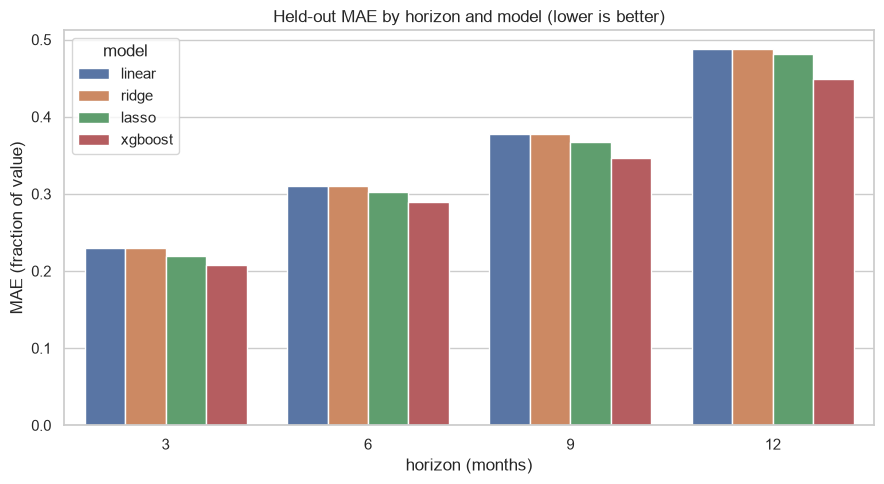

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=metrics, x="months", y="mae", hue="model", ax=ax)
ax.set_title("Held-out MAE by horizon and model (lower is better)")
ax.set_xlabel("horizon (months)")
ax.set_ylabel("MAE (fraction of value)")
plt.tight_layout()
plt.show()

XGBoost has the lowest MAE at every horizon, consistent with the age/value relationship being non-linear (a fixed-effect linear model can't fully capture a peak-and-decline curve or position-specific dynamics). We use the best model per horizon (by MAE) for the forward-looking predictions below.

## Predicted top value-risers

Applying each horizon's best model to every player's most recent valuation snapshot (within the last 12 months). **Caveats**: this only knows about age, position, and on-pitch performance — it has no signal on injuries, transfer rumors, contract situations, or club form, and very young/low-minutes players can produce large predicted swings off a small base, so treat these as a data-driven starting point rather than a forecast.

In [6]:
best_model_per_horizon = {
    months: min(results, key=lambda name: results[name]["mae"]) for months, results in all_results.items()
}
best_model_per_horizon

{3: 'xgboost', 6: 'xgboost', 9: 'xgboost', 12: 'xgboost'}

In [7]:
latest = latest_snapshot_per_player(panel)

all_preds = {}
top_risers_pct = {}
for months in HORIZONS_MONTHS:
    best_name = best_model_per_horizon[months]
    pipeline = all_results[months][best_name]["pipeline"]
    preds = predict_value_growth(pipeline, latest)
    preds["current_value_usd_m"] = preds["current_value_eur"] * USD_PER_EUR / 1_000_000
    preds["predicted_value_usd_m"] = preds["predicted_value_eur"] * USD_PER_EUR / 1_000_000
    preds["predicted_eur_change_usd_m"] = preds["predicted_eur_change"] * USD_PER_EUR / 1_000_000
    all_preds[months] = preds
    top_risers_pct[months] = preds.sort_values("predicted_pct_change", ascending=False).head(10)

display_cols = ["name", "sub_position", "age", "current_value_usd_m", "predicted_pct_change", "predicted_value_usd_m"]
for months in HORIZONS_MONTHS:
    print(f"=== Top predicted risers by % change: next {months} months (model: {best_model_per_horizon[months]}) ===")
    display(top_risers_pct[months][display_cols].round(2))

=== Top predicted risers by % change: next 3 months (model: xgboost) ===


,name,sub_position,age,current_value_usd_m,predicted_pct_change,predicted_value_usd_m
33507,Alex Cairns,Goalkeeper,33.41,0.05,3.14,0.22
33415,Charlie Crew,Defensive Midfield,19.97,0.16,1.87,0.47
32213,Louie Marsh,Second Striker,21.42,0.16,1.13,0.34
33351,Matai Akinmboni,Centre-Back,19.63,1.08,1.06,2.22
32242,Sam Curtis,Right-Back,20.01,0.19,1.05,0.39
33364,Harrison Jones,Attacking Midfield,21.44,0.16,1.01,0.33
33400,Caleb Kporha,Right-Back,19.89,1.08,0.95,2.10
33403,Chido Obi,Centre-Forward,18.51,5.40,0.91,10.32
33126,Nik Tzanev,Goalkeeper,29.38,0.11,0.87,0.20
33154,Dujuan Richards,Centre-Forward,20.54,0.54,0.84,1.00


=== Top predicted risers by % change: next 6 months (model: xgboost) ===


,name,sub_position,age,current_value_usd_m,predicted_pct_change,predicted_value_usd_m
33415,Charlie Crew,Defensive Midfield,19.97,0.16,2.94,0.64
32242,Sam Curtis,Right-Back,20.01,0.19,2.23,0.61
33401,Rio Cardines,Left-Back,19.92,0.32,2.08,1.00
32213,Louie Marsh,Second Striker,21.42,0.16,1.72,0.44
33162,Tammer Bany,Centre-Forward,22.61,0.27,1.59,0.70
33388,Rio Ngumoha,Left Winger,17.76,32.40,1.57,83.21
33364,Harrison Jones,Attacking Midfield,21.44,0.16,1.53,0.41
33393,Mohamadou Kanté,Defensive Midfield,20.70,1.08,1.29,2.48
33154,Dujuan Richards,Centre-Forward,20.54,0.54,1.29,1.24
33400,Caleb Kporha,Right-Back,19.89,1.08,1.25,2.43


=== Top predicted risers by % change: next 9 months (model: xgboost) ===


,name,sub_position,age,current_value_usd_m,predicted_pct_change,predicted_value_usd_m
33415,Charlie Crew,Defensive Midfield,19.97,0.16,2.79,0.61
32242,Sam Curtis,Right-Back,20.01,0.19,2.42,0.65
33401,Rio Cardines,Left-Back,19.92,0.32,2.07,0.99
33162,Tammer Bany,Centre-Forward,22.61,0.27,1.75,0.74
33364,Harrison Jones,Attacking Midfield,21.44,0.16,1.73,0.44
32213,Louie Marsh,Second Striker,21.42,0.16,1.67,0.43
32218,Bobby Wales,Centre-Forward,20.45,0.43,1.64,1.14
33393,Mohamadou Kanté,Defensive Midfield,20.70,1.08,1.63,2.84
33118,Ronan Kpakio,Right-Back,18.97,1.30,1.56,3.32
31833,Cameron Congreve,Right Winger,21.43,0.32,1.54,0.82


=== Top predicted risers by % change: next 12 months (model: xgboost) ===


,name,sub_position,age,current_value_usd_m,predicted_pct_change,predicted_value_usd_m
33415,Charlie Crew,Defensive Midfield,19.97,0.16,3.37,0.71
32242,Sam Curtis,Right-Back,20.01,0.19,2.59,0.68
32213,Louie Marsh,Second Striker,21.42,0.16,2.26,0.53
32218,Bobby Wales,Centre-Forward,20.45,0.43,2.13,1.35
33401,Rio Cardines,Left-Back,19.92,0.32,2.10,1.00
33154,Dujuan Richards,Centre-Forward,20.54,0.54,2.00,1.62
32153,Mark O'Mahony,Centre-Forward,20.87,0.49,1.97,1.44
33364,Harrison Jones,Attacking Midfield,21.44,0.16,1.95,0.48
33118,Ronan Kpakio,Right-Back,18.97,1.30,1.90,3.76
33400,Caleb Kporha,Right-Back,19.89,1.08,1.85,3.08


### The same question in dollar terms

Ranking by predicted % change favors very cheap, low-minutes players, where a small dollar move is a huge percentage swing (and can be noisy — a thin performance history makes for a shaky extrapolation). Ranking by predicted **absolute** dollar change instead surfaces players who are already valuable and projected to grow further — arguably the more decision-relevant view for "whose value will rise the most."

In [8]:
dollar_cols = ["name", "sub_position", "age", "current_value_usd_m", "predicted_eur_change_usd_m", "predicted_value_usd_m"]
for months in HORIZONS_MONTHS:
    top_by_dollar = all_preds[months].sort_values("predicted_eur_change_usd_m", ascending=False).head(10)
    print(f"=== Top predicted risers by $ change: next {months} months (model: {best_model_per_horizon[months]}) ===")
    display(top_by_dollar[dollar_cols].round(2))

=== Top predicted risers by $ change: next 3 months (model: xgboost) ===


,name,sub_position,age,current_value_usd_m,predicted_eur_change_usd_m,predicted_value_usd_m
33357,Junior Kroupi,Centre-Forward,19.95,75.6,23.32,98.92
32488,Ethan Nwaneri,Attacking Midfield,18.72,43.2,17.49,60.69
33385,Max Dowman,Right Winger,16.42,32.4,14.37,46.77
33388,Rio Ngumoha,Left Winger,17.76,32.4,14.23,46.63
33394,Ayden Heaven,Centre-Back,19.70,32.4,13.96,46.36
33252,Jarrad Branthwaite,Centre-Back,23.93,43.2,11.14,54.34
33250,Rayan Cherki,Attacking Midfield,22.80,97.2,10.99,108.19
33391,Giovanni Leoni,Centre-Back,19.45,27.0,9.37,36.37
33412,Josh Acheampong,Right-Back,20.08,27.0,8.90,35.90
33370,Lewis Miley,Central Midfield,20.09,27.0,8.43,35.43


=== Top predicted risers by $ change: next 6 months (model: xgboost) ===


,name,sub_position,age,current_value_usd_m,predicted_eur_change_usd_m,predicted_value_usd_m
33388,Rio Ngumoha,Left Winger,17.76,32.40,50.81,83.21
33385,Max Dowman,Right Winger,16.42,32.40,29.33,61.73
33357,Junior Kroupi,Centre-Forward,19.95,75.60,25.46,101.06
33405,Rayan,Right Winger,19.83,64.80,17.62,82.42
32488,Ethan Nwaneri,Attacking Midfield,18.72,43.20,17.00,60.20
33477,Nico O'Reilly,Left-Back,21.20,75.60,12.73,88.33
33463,Kobbie Mainoo,Central Midfield,21.12,75.60,10.19,85.79
33661,Bukayo Saka,Right Winger,24.74,118.80,10.12,128.92
33389,Harrison Armstrong,Central Midfield,19.37,12.96,10.11,23.07
33359,Chris Rigg,Attacking Midfield,18.96,27.00,10.08,37.08


=== Top predicted risers by $ change: next 9 months (model: xgboost) ===


,name,sub_position,age,current_value_usd_m,predicted_eur_change_usd_m,predicted_value_usd_m
33388,Rio Ngumoha,Left Winger,17.76,32.4,43.53,75.93
33385,Max Dowman,Right Winger,16.42,32.4,35.67,68.07
32488,Ethan Nwaneri,Attacking Midfield,18.72,43.2,29.17,72.37
33357,Junior Kroupi,Centre-Forward,19.95,75.6,21.91,97.51
33405,Rayan,Right Winger,19.83,64.8,18.93,83.73
33477,Nico O'Reilly,Left-Back,21.20,75.6,16.17,91.77
33463,Kobbie Mainoo,Central Midfield,21.12,75.6,14.27,89.87
33449,Mateus Fernandes,Central Midfield,21.90,54.0,12.79,66.79
33446,Myles Lewis-Skelly,Left-Back,19.69,48.6,12.63,61.23
33369,Leny Yoro,Centre-Back,20.55,54.0,12.07,66.07


=== Top predicted risers by $ change: next 12 months (model: xgboost) ===


,name,sub_position,age,current_value_usd_m,predicted_eur_change_usd_m,predicted_value_usd_m
33385,Max Dowman,Right Winger,16.42,32.40,53.92,86.32
33388,Rio Ngumoha,Left Winger,17.76,32.40,35.09,67.49
32488,Ethan Nwaneri,Attacking Midfield,18.72,43.20,32.53,75.73
33357,Junior Kroupi,Centre-Forward,19.95,75.60,29.74,105.34
33405,Rayan,Right Winger,19.83,64.80,27.48,92.28
33477,Nico O'Reilly,Left-Back,21.20,75.60,22.32,97.92
33449,Mateus Fernandes,Central Midfield,21.90,54.00,19.52,73.52
33394,Ayden Heaven,Centre-Back,19.70,32.40,19.09,51.49
33389,Harrison Armstrong,Central Midfield,19.37,12.96,18.01,30.97
33391,Giovanni Leoni,Centre-Back,19.45,27.00,17.72,44.72


### Biggest predicted 12-month risers, in dollar terms

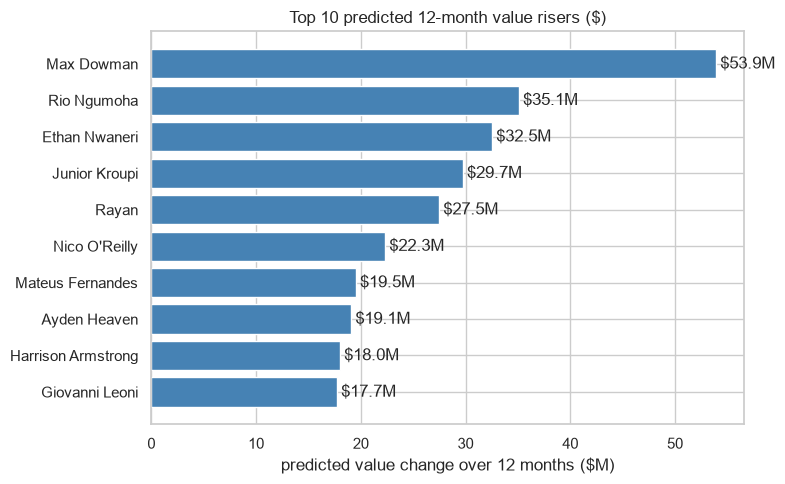

In [9]:
chart_data = all_preds[12].sort_values("predicted_eur_change_usd_m", ascending=False).head(10).sort_values("predicted_eur_change_usd_m")
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(chart_data["name"], chart_data["predicted_eur_change_usd_m"], color="steelblue")
ax.bar_label(bars, fmt="$%.1fM", padding=3)
ax.set_xlabel("predicted value change over 12 months ($M)")
ax.set_title("Top 10 predicted 12-month value risers ($)")
plt.tight_layout()
plt.show()